# Experiment 1: ResNet-50 at 320x320

This is `EXPERIMENT_1_320`. It changes only the input resolution from the `BASELINE_224` modeling setup. The official splits remain unchanged, checkpoint selection uses validation loss, and final test evaluation is disabled by default.

## 1. Setup

In [1]:
import gc
import json
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'src').exists():
    raise RuntimeError('Không tìm thấy thư mục src. Hãy mở notebook từ repo này.')

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('Project root:', PROJECT_ROOT)

Project root: C:\Users\ADMIN\Desktop\Code\Project\DL final\DL2026-Group5-Project30


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch.nn as nn
from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from torch.utils.data import DataLoader
from torchvision import transforms

from src.datasets.glaucoma_dataset import GlaucomaDataset, IDX_TO_CLASS
from src.models.resnet50 import ResNet50Classifier
from src.training.config import (
    CHECKPOINT_DIR,
    DEVICE,
    LEARNING_RATE,
    NUM_CLASSES,
    NUM_EPOCHS,
    RESULTS_FIGURES_DIR,
    RESULTS_METRICS_DIR,
    SEED,
    WEIGHT_DECAY,
    set_seed,
)
if not torch.cuda.is_available():
    raise RuntimeError('CUDA is not available in this notebook kernel')
DEVICE = torch.device('cuda:0')
set_seed()
sns.set_theme(style='whitegrid')

print('PyTorch:', torch.__version__)
print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB')

c:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.14.1+cu130
Device: cuda:0
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
VRAM: 7.96 GB


## 2. Experiment 1 configuration

Start with batch size 16 and AMP on the 8 GB GPU. A CUDA OOM restarts training from epoch 1 at batch size 8, then 4, and records the fallback.

In [3]:
EXPERIMENT_NAME = 'EXPERIMENT_1_320'
BASELINE_NAME = 'BASELINE_224'
IMAGE_SIZE = 320
BATCH_SIZE = 16
BATCH_SIZE_CANDIDATES = (BATCH_SIZE, 8, 4)
AMP_ENABLED = True
RUN_FINAL_TEST = False  # Enable only after selection using validation data.
EPOCHS = NUM_EPOCHS
PATIENCE = 5
MODEL_NAME = 'resnet50_320'
CLASS_NAMES = [IDX_TO_CLASS[index] for index in range(NUM_CLASSES)]
CHECKPOINT_PATH = Path(CHECKPOINT_DIR) / f'{MODEL_NAME}_best.pt'
assert IMAGE_SIZE == 320
assert CHECKPOINT_PATH != Path(CHECKPOINT_DIR) / 'resnet50_best.pt'

print({
    'experiment': EXPERIMENT_NAME,
    'baseline': BASELINE_NAME,
    'image_size': IMAGE_SIZE,
    'initial_batch_size': BATCH_SIZE,
    'amp_enabled': AMP_ENABLED,
    'epochs': EPOCHS,
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'patience': PATIENCE,
    'checkpoint_criterion': 'lowest validation CrossEntropyLoss',
    'run_final_test': RUN_FINAL_TEST,
    'classes': CLASS_NAMES,
})

{'experiment': 'EXPERIMENT_1_320', 'baseline': 'BASELINE_224', 'image_size': 320, 'initial_batch_size': 16, 'amp_enabled': True, 'epochs': 20, 'learning_rate': 0.0001, 'weight_decay': 0.0001, 'patience': 5, 'checkpoint_criterion': 'lowest validation CrossEntropyLoss', 'run_final_test': False, 'classes': ['normal', 'early', 'advanced']}


## 3. Notebook-local 320x320 data pipeline

The shared dataset code is unchanged. Augmentation and normalization match the baseline; only the resize target is different.

In [4]:
train_transform_320 = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

eval_transform_320 = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

raw_dataset = load_dataset('moondream/glaucoma-detection')

def build_experiment_loaders(batch_size):
    train_data = GlaucomaDataset(raw_dataset['train'], transform=train_transform_320)
    val_data = GlaucomaDataset(raw_dataset['validation'], transform=eval_transform_320)
    test_data = GlaucomaDataset(raw_dataset['test'], transform=eval_transform_320)
    return (
        DataLoader(train_data, batch_size=batch_size, shuffle=True),
        DataLoader(val_data, batch_size=batch_size, shuffle=False),
        DataLoader(test_data, batch_size=batch_size, shuffle=False),
    )

def verify_experiment_loaders(train_loader, val_loader, test_loader):
    assert len(train_loader.dataset) == 2847
    assert len(val_loader.dataset) == 1259
    assert len(test_loader.dataset) == 1272
    print('Train samples:', len(train_loader.dataset))
    print('Validation samples:', len(val_loader.dataset))
    print('Test samples:', len(test_loader.dataset))

    images, labels = next(iter(train_loader))
    print('Image batch:', tuple(images.shape))
    print('Label batch:', tuple(labels.shape))
    assert images.shape[1:] == (3, 320, 320)
    assert labels.min() >= 0 and labels.max() < NUM_CLASSES

train_loader, val_loader, test_loader = build_experiment_loaders(BATCH_SIZE)
verify_experiment_loaders(train_loader, val_loader, test_loader)

Train samples: 2847
Validation samples: 1259
Test samples: 1272
Image batch: (16, 3, 320, 320)
Label batch: (16,)


## 4. Build the unchanged pretrained ResNet-50

The architecture, ImageNet pretrained weights, full-backbone fine-tuning, AdamW settings, and unweighted cross-entropy loss match the baseline.

In [5]:
def build_model_and_optimizer():
    model = ResNet50Classifier(
        num_classes=NUM_CLASSES,
        pretrained=True,
        freeze_features=False,
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )
    return model, optimizer

loss_fn = nn.CrossEntropyLoss()
probe_model, probe_optimizer = build_model_and_optimizer()
trainable_parameters = sum(p.numel() for p in probe_model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable_parameters:,}')
del probe_model, probe_optimizer
torch.cuda.empty_cache()

Trainable parameters: 23,514,179


## 5. Train with AMP and validation-loss checkpointing

AMP changes execution precision only. There is no scheduler, class weighting, ordinal loss, TTA, differential learning rate, or gradient accumulation.

In [6]:
def compute_metrics(labels, predictions):
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        labels, predictions, labels=range(NUM_CLASSES), average='macro', zero_division=0
    )
    return {
        'accuracy': float(accuracy_score(labels, predictions)),
        'balanced_accuracy': float(balanced_accuracy_score(labels, predictions)),
        'macro_precision': float(macro_precision),
        'macro_recall': float(macro_recall),
        'macro_f1': float(macro_f1),
        'qwk': float(cohen_kappa_score(labels, predictions, weights='quadratic')),
    }

@torch.no_grad()
def evaluate_experiment(model, dataloader):
    model.eval()
    total_loss = 0.0
    predictions, labels_all = [], []
    for images, labels in dataloader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        total_loss += loss.item() * images.size(0)
        predictions.extend(outputs.argmax(dim=1).cpu().tolist())
        labels_all.extend(labels.cpu().tolist())
    metrics = compute_metrics(labels_all, predictions)
    metrics['loss'] = float(total_loss / len(dataloader.dataset))
    return metrics, predictions, labels_all

def fit_experiment(model, optimizer, train_loader, val_loader):
    history = {'train_loss': [], 'val_loss': [], 'val_metrics': []}
    scaler = torch.amp.GradScaler('cuda', enabled=AMP_ENABLED)
    best_val_loss = float('inf')
    best_epoch = None
    best_val_metrics = None
    epochs_without_improvement = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            with torch.autocast(device_type='cuda', dtype=torch.float16, enabled=AMP_ENABLED):
                outputs = model(images)
                loss = loss_fn(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_train_loss += loss.item() * images.size(0)

        train_loss = total_train_loss / len(train_loader.dataset)
        val_metrics, _, _ = evaluate_experiment(model, val_loader)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['val_metrics'].append(val_metrics)
        improved = val_metrics['loss'] < best_val_loss
        print(
            f"Epoch {epoch}/{EPOCHS} - train_loss: {train_loss:.4f} - "
            f"val_loss: {val_metrics['loss']:.4f} - val_acc: {val_metrics['accuracy']:.4f} - "
            f"val_macro_f1: {val_metrics['macro_f1']:.4f} - val_qwk: {val_metrics['qwk']:.4f}"
            + ('  (best validation loss)' if improved else '')
        )
        if improved:
            best_val_loss = val_metrics['loss']
            best_epoch = epoch
            best_val_metrics = val_metrics.copy()
            epochs_without_improvement = 0
            CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), CHECKPOINT_PATH)
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= PATIENCE:
                print(f'No validation-loss improvement for {PATIENCE} epochs; stopping.')
                break
    return history, best_epoch, best_val_metrics

oom_occurred = False
for batch_size in BATCH_SIZE_CANDIDATES:
    gc.collect()
    torch.cuda.empty_cache()
    set_seed(SEED)
    train_loader, val_loader, test_loader = build_experiment_loaders(batch_size)
    print(f'\nAttempting Experiment 1 with batch size {batch_size}')
    verify_experiment_loaders(train_loader, val_loader, test_loader)
    set_seed(SEED)  # Sanity-check iteration must not change training initialization/order.
    model, optimizer = build_model_and_optimizer()
    try:
        history, best_epoch, best_val_metrics = fit_experiment(
            model, optimizer, train_loader, val_loader
        )
        actual_batch_size = batch_size
        break
    except RuntimeError as error:
        if 'out of memory' not in str(error).lower():
            raise
        oom_occurred = True
        print(f'CUDA OOM at batch size {batch_size}; restarting from epoch 1.')
        del model, optimizer
        gc.collect()
        torch.cuda.empty_cache()
else:
    raise RuntimeError('CUDA OOM at batch sizes 16, 8, and 4.')

print({
    'experiment': EXPERIMENT_NAME,
    'actual_batch_size': actual_batch_size,
    'amp_enabled': AMP_ENABLED,
    'cuda_oom_occurred': oom_occurred,
    'best_epoch': best_epoch,
    'best_val_loss': best_val_metrics['loss'],
})

assert CHECKPOINT_PATH.exists(), f'Không tìm thấy checkpoint: {CHECKPOINT_PATH}'
print('Best checkpoint:', CHECKPOINT_PATH)


Attempting Experiment 1 with batch size 16
Train samples: 2847
Validation samples: 1259
Test samples: 1272
Image batch: (16, 3, 320, 320)
Label batch: (16,)
Epoch 1/20 - train_loss: 0.7781 - val_loss: 0.6152 - val_acc: 0.7434 - val_macro_f1: 0.7169 - val_qwk: 0.7627  (best validation loss)
Epoch 2/20 - train_loss: 0.5598 - val_loss: 0.5993 - val_acc: 0.7403 - val_macro_f1: 0.6906 - val_qwk: 0.7001  (best validation loss)
Epoch 3/20 - train_loss: 0.4714 - val_loss: 0.5256 - val_acc: 0.7951 - val_macro_f1: 0.7653 - val_qwk: 0.7587  (best validation loss)
Epoch 4/20 - train_loss: 0.3678 - val_loss: 0.4522 - val_acc: 0.8197 - val_macro_f1: 0.7905 - val_qwk: 0.8198  (best validation loss)
Epoch 5/20 - train_loss: 0.2969 - val_loss: 0.4671 - val_acc: 0.8308 - val_macro_f1: 0.8115 - val_qwk: 0.8159
Epoch 6/20 - train_loss: 0.2174 - val_loss: 0.3590 - val_acc: 0.8626 - val_macro_f1: 0.8415 - val_qwk: 0.8651  (best validation loss)
Epoch 7/20 - train_loss: 0.1794 - val_loss: 0.3645 - val_acc: 

## 6. Training curves

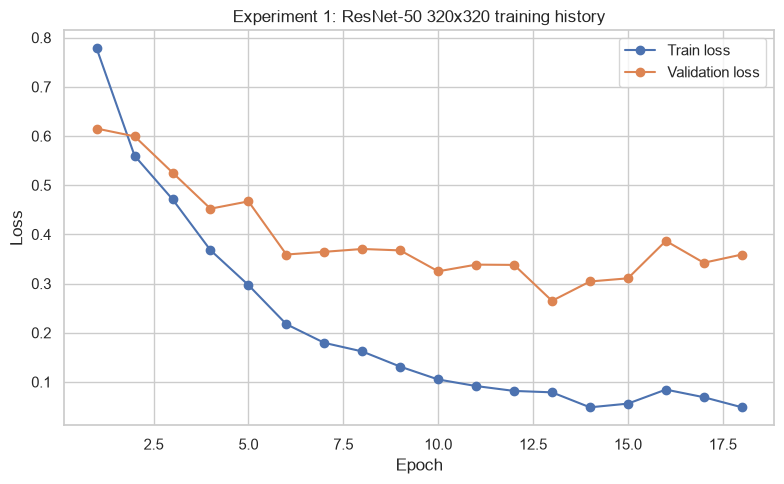

In [7]:
figure_dir = Path(RESULTS_FIGURES_DIR)
figure_dir.mkdir(parents=True, exist_ok=True)

epochs_ran = range(1, len(history['train_loss']) + 1)
plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history['train_loss'], marker='o', label='Train loss')
plt.plot(epochs_ran, history['val_loss'], marker='o', label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Experiment 1: ResNet-50 320x320 training history')
plt.legend()
plt.tight_layout()
plt.savefig(figure_dir / 'resnet50_320_training_curve.png', dpi=160)
plt.show()

## 7. Selected-checkpoint validation evaluation

Reload the checkpoint with the lowest validation cross-entropy loss and report all requested validation metrics. The test split is not used here.

In [8]:
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=True))
selected_val_metrics, val_predictions, val_labels = evaluate_experiment(model, val_loader)

print('Selected checkpoint validation metrics:')
print(json.dumps(selected_val_metrics, indent=2))
print()
print(classification_report(
    val_labels,
    val_predictions,
    labels=range(NUM_CLASSES),
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0,
))

Selected checkpoint validation metrics:
{
  "accuracy": 0.9030976965845909,
  "balanced_accuracy": 0.8917169431875314,
  "macro_precision": 0.8936326513429317,
  "macro_recall": 0.8917169431875314,
  "macro_f1": 0.8921901926829198,
  "qwk": 0.9035011766608437,
  "loss": 0.26483874226534904
}

              precision    recall  f1-score   support

      normal     0.8692    0.9231    0.8953       403
       early     0.8547    0.8109    0.8322       312
    advanced     0.9570    0.9412    0.9490       544

    accuracy                         0.9031      1259
   macro avg     0.8936    0.8917    0.8922      1259
weighted avg     0.9035    0.9031    0.9029      1259



## 8. Validation confusion matrix

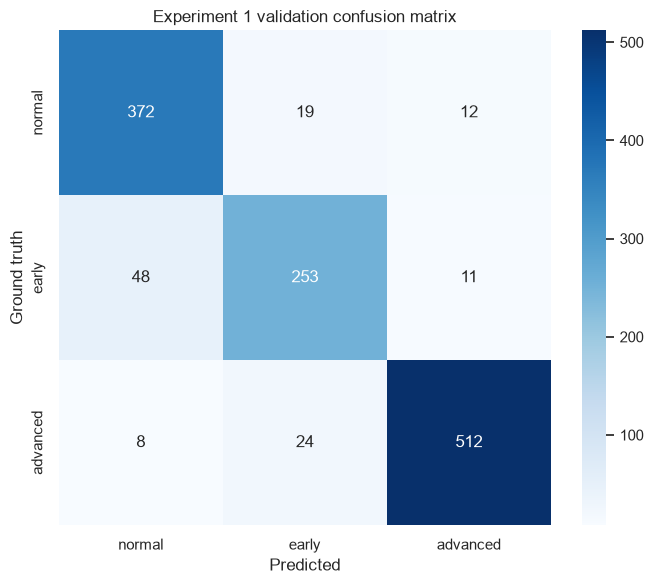

In [9]:
matrix = confusion_matrix(
    val_labels,
    val_predictions,
    labels=range(NUM_CLASSES),
)

plt.figure(figsize=(7, 6))
sns.heatmap(
    matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
)
plt.xlabel('Predicted')
plt.ylabel('Ground truth')
plt.title('Experiment 1 validation confusion matrix')
plt.tight_layout()
plt.savefig(figure_dir / 'resnet50_320_validation_confusion_matrix.png', dpi=160)
plt.show()

## 9. Save Experiment 1 metrics and compare with BASELINE_224

In [10]:
metrics_dir = Path(RESULTS_METRICS_DIR)
metrics_dir.mkdir(parents=True, exist_ok=True)
metrics_path = metrics_dir / 'resnet50_320.json'

test_metrics = None
if RUN_FINAL_TEST:
    test_metrics, test_predictions, test_labels = evaluate_experiment(model, test_loader)
    print('Final test metrics (not used for model selection):')
    print(json.dumps(test_metrics, indent=2))
else:
    print('Final test evaluation skipped. Set RUN_FINAL_TEST=True only after validation selection.')

with metrics_path.open('w', encoding='utf-8') as file:
    json.dump(
        {
            'experiment': EXPERIMENT_NAME,
            'baseline': BASELINE_NAME,
            'model': 'ResNet50Classifier(pretrained=True, freeze_features=False)',
            'class_mapping': {str(index): name for index, name in enumerate(CLASS_NAMES)},
            'image_size': IMAGE_SIZE,
            'batch_size': actual_batch_size,
            'amp_enabled': AMP_ENABLED,
            'cuda_oom_occurred': oom_occurred,
            'epochs_completed': len(history['train_loss']),
            'maximum_epochs': EPOCHS,
            'early_stopping_patience': PATIENCE,
            'best_epoch': best_epoch,
            'checkpoint_criterion': 'lowest validation CrossEntropyLoss',
            'optimizer': 'AdamW',
            'learning_rate': LEARNING_RATE,
            'weight_decay': WEIGHT_DECAY,
            'validation_metrics': selected_val_metrics,
            'test_metrics': test_metrics,
        },
        file,
        indent=2,
    )

print('Saved metrics:', metrics_path)
print('Saved figures:', figure_dir)
print('Saved checkpoint:', CHECKPOINT_PATH)

baseline_path = metrics_dir / 'resnet50.json'
baseline_validation = {}
if baseline_path.exists():
    with baseline_path.open(encoding='utf-8') as file:
        baseline_validation = json.load(file).get('validation_metrics', {})

comparison_rows = [
    ('Val Accuracy', 'accuracy'),
    ('Val Balanced Acc', 'balanced_accuracy'),
    ('Val Macro F1', 'macro_f1'),
    ('Val QWK', 'qwk'),
    ('Best Val Loss', 'loss'),
]
print('\nMetric'.ljust(24), BASELINE_NAME.rjust(18), EXPERIMENT_NAME.rjust(20))
print('-' * 64)
for label, key in comparison_rows:
    baseline_value = baseline_validation.get(key)
    baseline_text = f'{baseline_value:.4f}' if baseline_value is not None else 'not available'
    print(label.ljust(24), baseline_text.rjust(18), f"{selected_val_metrics[key]:.4f}".rjust(20))
if not baseline_validation:
    print('BASELINE_224 validation values must be obtained from the existing baseline run; test metrics are not substituted.')

Final test evaluation skipped. Set RUN_FINAL_TEST=True only after validation selection.
Saved metrics: results\metrics\resnet50_320.json
Saved figures: results\figures
Saved checkpoint: checkpoints\resnet50_320_best.pt

Metric                        BASELINE_224     EXPERIMENT_1_320
----------------------------------------------------------------
Val Accuracy                  not available               0.9031
Val Balanced Acc              not available               0.8917
Val Macro F1                  not available               0.8922
Val QWK                       not available               0.9035
Best Val Loss                 not available               0.2648
BASELINE_224 validation values must be obtained from the existing baseline run; test metrics are not substituted.
